=== AKURASI MODEL ===
Accuracy Score: 100.00%

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

        cuti       1.00      1.00      1.00         2
         krs       1.00      1.00      1.00         2
   transkrip       1.00      1.00      1.00         2
         ukt       1.00      1.00      1.00         2

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



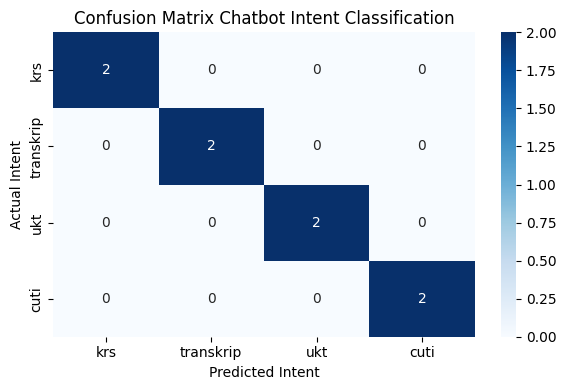


=== SIMULASI CHATBOT AKADEMIK ===
Mahasiswa : kapan terakhir bayar ukt?
Bot       : [UKT] Pembayaran UKT dapat dilakukan via ATM/Mobile Banking menggunakan Virtual Account (VA) sebelum tenggat waktu resmi. (Confidence: 46.2%)

Mahasiswa : gimana cara krsan online?
Bot       : [KRS] Pengisian KRS dilakukan secara online melalui portal akademik pada menu 'KRS Online' sesuai jadwal kalender akademik. (Confidence: 31.2%)

Mahasiswa : mau minta transkrip nilai dong
Bot       : [TRANSKRIP] Pengajuan transkrip nilai dapat dilakukan melalui Loket Tata Usaha Fakultas dengan melampirkan bebas pustaka. (Confidence: 61.2%)

Mahasiswa : apa syarat ambil cuti kuliah?
Bot       : [CUTI] Pengajuan cuti akademik memerlukan Surat Permohonan yang disetujui Dosen Pembimbing Akademik dan Dekan Fakultas. (Confidence: 52.4%)



In [2]:
# ==============================================================================
# TUGAS PRAKTIKUM AI: CHATBOT LAYANAN AKADEMIK BERBASIS NLP (OPTIMIZED)
# Bidang AI: Natural Language Processing (NLP)
# Model: TF-IDF Vectorizer + Naive Bayes Classifier
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

# 1. Menyiapkan Dataset Dataset Intent Akademik yang Dilengkapi
dataset = [
    # Intent: KRS
    ("bagaimana cara mengisi krs online", "krs"),
    ("kapan jadwal pengisian krs semester ini", "krs"),
    ("di mana letak menu krs pada portal akademik", "krs"),
    ("apa syarat bisa mengisi krs", "krs"),
    ("jadwal krs dibuka tanggal berapa", "krs"),
    ("cara tambah matakuliah di krs", "krs"),
    ("gimana cara krsan online", "krs"),
    ("panduan pengisian krs mahasiswa", "krs"),
    ("sistem krs error saat simpan", "krs"),
    ("kapan batas akhir input krs", "krs"),

    # Intent: Transkrip
    ("bagaimana cara mencetak transkrip nilai", "transkrip"),
    ("di mana tempat minta transkrip nilai akademik", "transkrip"),
    ("apa syarat pengajuan transkrip nilai", "transkrip"),
    ("siapa yang menandatangani transkrip nilai", "transkrip"),
    ("prosedur cetak transkrip sementara", "transkrip"),
    ("mau minta transkrip nilai dong", "transkrip"),
    ("cara ambil transkrip nilai kumulatif", "transkrip"),
    ("berapa hari cetak transkrip nilai", "transkrip"),
    ("syarat minta nilai semester", "transkrip"),
    ("loket pengurusan transkrip nilai", "transkrip"),

    # Intent: UKT
    ("kapan batas akhir pembayaran ukt", "ukt"),
    ("bagaimana cara bayar ukt lewat mobile banking", "ukt"),
    ("di mana mendapatkan nomor virtual account ukt", "ukt"),
    ("apakah bisa mengangsur pembayaran ukt", "ukt"),
    ("prosedur pengajuan keringanan ukt", "ukt"),
    ("kapan terakhir bayar ukt", "ukt"),
    ("cara bayar ukt via atm", "ukt"),
    ("nominal ukt semester ini berapa", "ukt"),
    ("info pembayaran biaya kuliah ukt", "ukt"),
    ("rekening pembayaran ukt kampus", "ukt"),

    # Intent: Cuti
    ("bagaimana cara mengajukan cuti akademik", "cuti"),
    ("apa saja syarat untuk ambil cuti kuliah", "cuti"),
    ("berapa lama maksimal mahasiswa bisa cuti", "cuti"),
    ("ke mana menyerahkan berkas pengajuan cuti", "cuti"),
    ("prosedur aktif kembali setelah cuti akademik", "cuti"),
    ("apa syarat ambil cuti kuliah", "cuti"),
    ("formulir pengajuan cuti kuliah", "cuti"),
    ("batas maksimal alpa cuti akademik", "cuti"),
    ("biaya administrasi cuti akademik", "cuti"),
    ("persyaratan syarat cuti semester", "cuti")
]

# Jawaban Berdasarkan Intent
responses = {
    "krs": "Pengisian KRS dilakukan secara online melalui portal akademik pada menu 'KRS Online' sesuai jadwal kalender akademik.",
    "transkrip": "Pengajuan transkrip nilai dapat dilakukan melalui Loket Tata Usaha Fakultas dengan melampirkan bebas pustaka.",
    "ukt": "Pembayaran UKT dapat dilakukan via ATM/Mobile Banking menggunakan Virtual Account (VA) sebelum tenggat waktu resmi.",
    "cuti": "Pengajuan cuti akademik memerlukan Surat Permohonan yang disetujui Dosen Pembimbing Akademik dan Dekan Fakultas."
}

# 2. Preprocessing & Ekstraksi Data
df = pd.DataFrame(dataset, columns=["text", "intent"])
X = df["text"]
y = df["intent"]

# Pembagian Train & Test Data (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 3. Membangun Pipeline NLP (TF-IDF + Naive Bayes)
model_pipeline = make_pipeline(
    TfidfVectorizer(ngram_range=(1, 2)),
    MultinomialNB()
)

# Pelatihan Model
model_pipeline.fit(X_train, y_train)

# 4. Evaluasi Model
y_pred = model_pipeline.predict(X_test)
print("=== AKURASI MODEL ===")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, zero_division=0))

# Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=list(responses.keys()))
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(responses.keys()),
            yticklabels=list(responses.keys()))
plt.title('Confusion Matrix Chatbot Intent Classification')
plt.xlabel('Predicted Intent')
plt.ylabel('Actual Intent')
plt.tight_layout()
plt.show()

# 5. Fungsi Uji Coba Chatbot
def get_chatbot_response(user_text):
    intent = model_pipeline.predict([user_text])[0]
    probabilities = model_pipeline.predict_proba([user_text]).max()

    if probabilities < 0.25:
        return "Maaf, saya belum memahami pertanyaan Anda. Silakan hubungi layanan staf akademik."

    return f"[{intent.upper()}] {responses[intent]} (Confidence: {probabilities*100:.1f}%)"

# Simulasi Pertanyaan Baru (Uji Coba)
print("\n=== SIMULASI CHATBOT AKADEMIK ===")
test_queries = [
    "kapan terakhir bayar ukt?",
    "gimana cara krsan online?",
    "mau minta transkrip nilai dong",
    "apa syarat ambil cuti kuliah?"
]

for query in test_queries:
    print(f"Mahasiswa : {query}")
    print(f"Bot       : {get_chatbot_response(query)}\n")